In [16]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
insurance = pd.read_csv('c:/data/insurance.csv')
insurance.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance.shape

(1338, 7)

In [5]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
insurance.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

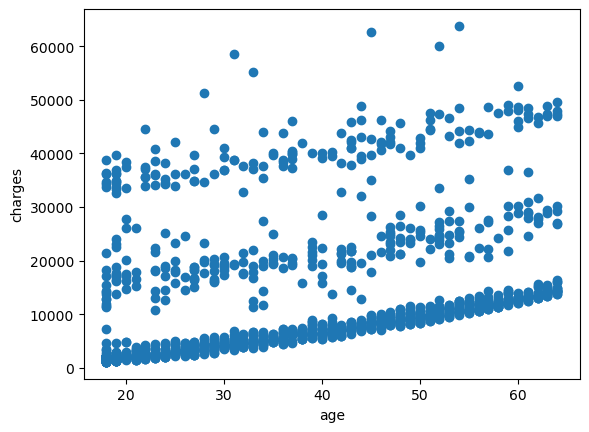

In [22]:
plt.scatter(x='age',y='charges',data=insurance)
plt.xlabel('age')
plt.ylabel('charges')

plt.show()

In [14]:
X=insurance[['age']]
y=insurance['charges']

In [17]:
model=LinearRegression()
model.fit(X,y)

LinearRegression()

In [19]:
w,b=model.coef_,model.intercept_
w,b


(array([257.72261867]), np.float64(3165.885006063021))

In [20]:
y_predict=model.predict(X)
y_predict

array([ 8062.61476073,  7804.89214207, 10382.11832874, ...,
        7804.89214207,  8578.05999807, 18886.96474474])

In [21]:
X.age*w[0]+b

0        8062.614761
1        7804.892142
2       10382.118329
3       11670.731422
4       11413.008803
            ...     
1333    16052.015939
1334     7804.892142
1335     7804.892142
1336     8578.059998
1337    18886.964745
Name: age, Length: 1338, dtype: float64

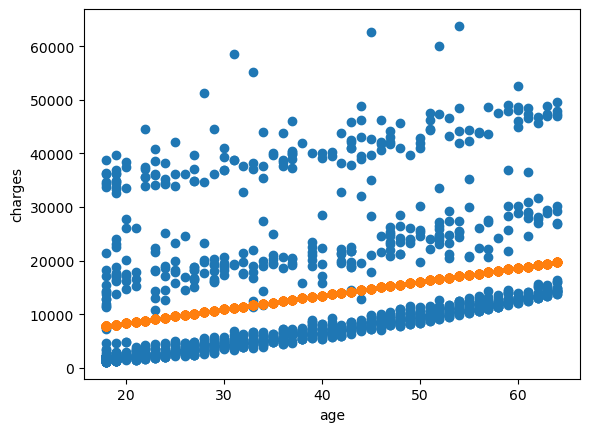

In [23]:
plt.scatter(x='age',y='charges',data=insurance)
plt.scatter(x=insurance.age,y=y_predict)
plt.xlabel('age')
plt.ylabel('charges')

plt.show()

In [26]:
model.score(X,y)*100

8.940589967885803

In [28]:
insurance.groupby('smoker').describe()['charges']

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268298,5993.781819,1121.8739,3986.438700,7345.40530,11362.887050,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


In [29]:
insurance=pd.get_dummies(insurance,columns=['smoker'],dtype='int32')
insurance.head()

,age,gender,bmi,children,region,charges,smoker_no,smoker_yes
0,19,female,27.900,0,southwest,16884.92400,0,1
1,18,male,33.770,1,southeast,1725.55230,1,0
2,28,male,33.000,3,southeast,4449.46200,1,0
3,33,male,22.705,0,northwest,21984.47061,1,0
4,32,male,28.880,0,northwest,3866.85520,1,0


In [57]:
X=insurance[['age','smoker_yes']]
y=insurance['charges']

In [58]:
model.fit(X,y)

LinearRegression()

In [60]:
y_predict= model.predict(X)
y_predict

array([26686.23098893,  2556.05498639,  5304.76684514, ...,
        2556.05498639,  3380.66854402, 38230.82079568])

In [61]:
w,b=model.coef_,model.intercept_
w,b

(array([  274.87118587, 23855.30481666]), np.float64(-2391.6263593585463))

In [62]:
X.age*w[0]+X.smoker_yes*w[1]+b

0       26686.230989
1        2556.054986
2        5304.766845
3        6679.122775
4        6404.251589
            ...     
1333    11351.932934
1334     2556.054986
1335     2556.054986
1336     3380.668544
1337    38230.820796
Length: 1338, dtype: float64

In [63]:
model.score(X,y)

0.72140082605772

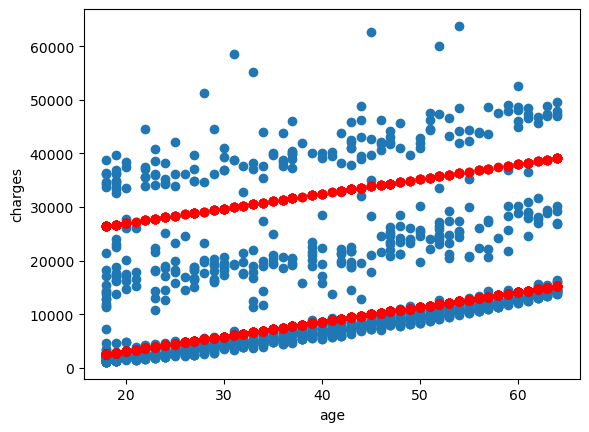

In [64]:
plt.scatter(x='age',y='charges',data=insurance)
plt.scatter(x=insurance.age,y=y_predict,c='red')

plt.xlabel('age')
plt.ylabel('charges')
plt.show()

In [65]:
X=insurance[['age','smoker_yes','bmi']]
y=insurance['charges']

In [66]:
model.fit(X,y)
model.score(X,y)

0.7474771588119513

In [67]:
insurance['bmi_30']=insurance.bmi.apply(lambda x : 1 if x>=30 else 0)
insurance.head()

,age,gender,bmi,children,region,charges,smoker_no,smoker_yes,bmi_30
0,19,female,27.900,0,southwest,16884.92400,0,1,0
1,18,male,33.770,1,southeast,1725.55230,1,0,1
2,28,male,33.000,3,southeast,4449.46200,1,0,1
3,33,male,22.705,0,northwest,21984.47061,1,0,0
4,32,male,28.880,0,northwest,3866.85520,1,0,0


In [68]:
X=insurance[['age','smoker_yes','bmi_30']]
y=insurance['charges']

In [69]:
model.fit(X,y)
model.score(X,y)

0.7510542445314582

In [73]:
y_predict= model.predict(X)
y_predict

array([24717.45289326,  4806.70905808,  7427.68779388, ...,
        4806.70905808,  1401.66406465, 35725.56358362])

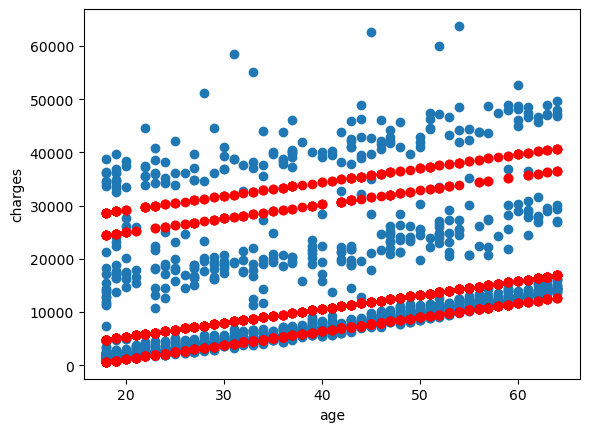

In [74]:
plt.scatter(x='age',y='charges',data=insurance)
plt.scatter(x=insurance.age,y=y_predict,c='red')

plt.xlabel('age')
plt.ylabel('charges')
plt.show()

In [76]:
added=insurance ['smoker_bmi_30']=insurance.smoker_yes*insurance.bmi_30
insurance.head()

,age,gender,bmi,children,region,charges,smoker_no,smoker_yes,bmi_30,smoker_bmi_30
0,19,female,27.900,0,southwest,16884.92400,0,1,0,0
1,18,male,33.770,1,southeast,1725.55230,1,0,1,0
2,28,male,33.000,3,southeast,4449.46200,1,0,1,0
3,33,male,22.705,0,northwest,21984.47061,1,0,0,0
4,32,male,28.880,0,northwest,3866.85520,1,0,0,0


In [77]:
insurance[insurance.smoker_bmi_30==1]

,age,gender,bmi,children,region,charges,smoker_no,smoker_yes,bmi_30,smoker_bmi_30
14,27,male,42.130,0,southeast,39611.75770,0,1,1,1
19,30,female,35.300,0,southwest,36837.46700,0,1,1,1
23,34,female,31.920,1,northeast,37701.87680,0,1,1,1
29,31,male,36.300,2,southwest,38711.00000,0,1,1,1
30,22,male,35.600,0,southwest,35585.57600,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1300,45,male,30.360,0,southeast,62592.87309,0,1,1,1
1301,62,male,30.875,3,northwest,46718.16325,0,1,1,1
1308,25,female,30.200,0,southwest,33900.65300,0,1,1,1
1313,19,female,34.700,2,southwest,36397.57600,0,1,1,1


In [78]:
X=insurance[['age','smoker_yes','smoker_bmi_30']]
y=insurance['charges']

In [79]:
model.fit(X,y)
model.score(X,y)

0.8584922811178519

In [80]:
y_predict= model.predict(X)
y_predict

array([16312.77047702,  2698.2820746 ,  5380.48711176, ...,
        2698.2820746 ,  3502.94358575, 27578.03163307])

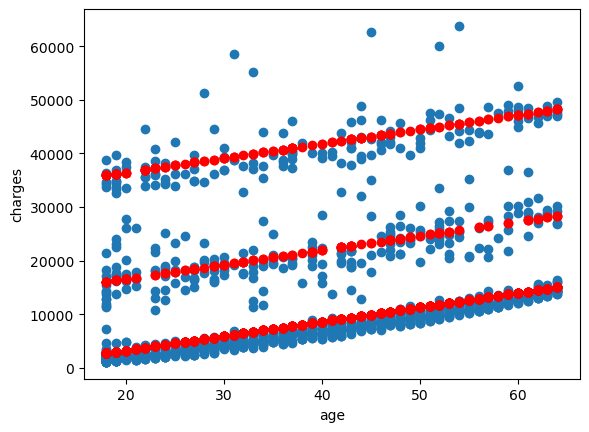

In [81]:
plt.scatter(x='age',y='charges',data=insurance)
plt.scatter(x=insurance.age,y=y_predict,c='red')

plt.xlabel('age')
plt.ylabel('charges')
plt.show()